In [1]:
# HealthGuard AI - Kidney Disease Model Training
# Author: HealthGuard AI Team
# Date: 2026
# Version: 2.0

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, roc_auc_score,
                             classification_report,
                             roc_curve, auc)
from sklearn.model_selection import (cross_val_score,
                                     GridSearchCV,
                                     StratifiedKFold)
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8')

print("=" * 50)
print("  HealthGuard AI - Kidney Disease Model Training v2.0")
print("=" * 50)
print("Libraries Loaded Successfully!")

  HealthGuard AI - Kidney Disease Model Training v2.0
Libraries Loaded Successfully!


In [2]:
# Load Data

X_train = pd.read_csv("E:/HealthGuard_AI/data/processed/kidney_X_train.csv")
X_test = pd.read_csv("E:/HealthGuard_AI/data/processed/kidney_X_test.csv")
y_train = pd.read_csv("E:/HealthGuard_AI/data/processed/kidney_y_train.csv").values.ravel()
y_test = pd.read_csv("E:/HealthGuard_AI/data/processed/kidney_y_test.csv").values.ravel()

print("Data Loaded Successfully!")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"\nTraining Class Distribution:")
print(f"Normal: {(y_train==0).sum()}")
print(f"CKD: {(y_train==1).sum()}")

Data Loaded Successfully!
X_train Shape: (256, 25)
X_test Shape: (62, 25)

Training Class Distribution:
Normal: 128
CKD: 128


In [3]:
# Step 0: Add Noise to Prevent Overfitting
# Dataset is too clean - models memorize it

print("=" * 50)
print("STEP 0: RELOAD WITH NOISE + NEW SPLIT")
print("=" * 50)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df_kidney = pd.read_csv(
    "E:/HealthGuard_AI/data/processed/kidney_cleaned_final.csv")

print(f"Dataset Shape: {df_kidney.shape}")

X = df_kidney.drop('classification', axis=1)
y = df_kidney['classification']

# Add small random noise to numeric features
# This prevents memorization
np.random.seed(42)
noise_factor = 0.05
X_noisy = X + np.random.normal(0, noise_factor, X.shape)

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X_noisy, y,
    test_size=0.30,
    random_state=42,
    stratify=y)

y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape: {X_test.shape}")
print(f"\nTrain - Normal: {(y_train==0).sum()}, CKD: {(y_train==1).sum()}")
print(f"Test  - Normal: {(y_test==0).sum()}, CKD: {(y_test==1).sum()}")
print("\nNoise Added - Overfitting Prevention!")

STEP 0: RELOAD WITH NOISE + NEW SPLIT
Dataset Shape: (310, 26)
X_train Shape: (217, 25)
X_test Shape: (93, 25)

Train - Normal: 105, CKD: 112
Test  - Normal: 45, CKD: 48

Noise Added - Overfitting Prevention!


STEP 1: CROSS VALIDATION (5-FOLD)
Cross Validation Results:
----------------------------------------

Logistic Regression:
  Mean F1: 0.9956
  Std F1:  0.0089
  Scores:  [1.     0.9778 1.     1.     1.    ]

Random Forest:
  Mean F1: 0.9956
  Std F1:  0.0089
  Scores:  [1.     1.     1.     0.9778 1.    ]

XGBoost:
  Mean F1: 0.9913
  Std F1:  0.0107
  Scores:  [0.9787 1.     0.9778 1.     1.    ]

SVM:
  Mean F1: 1.0000
  Std F1:  0.0000
  Scores:  [1. 1. 1. 1. 1.]

Neural Network:
  Mean F1: 0.9956
  Std F1:  0.0089
  Scores:  [1.     0.9778 1.     1.     1.    ]


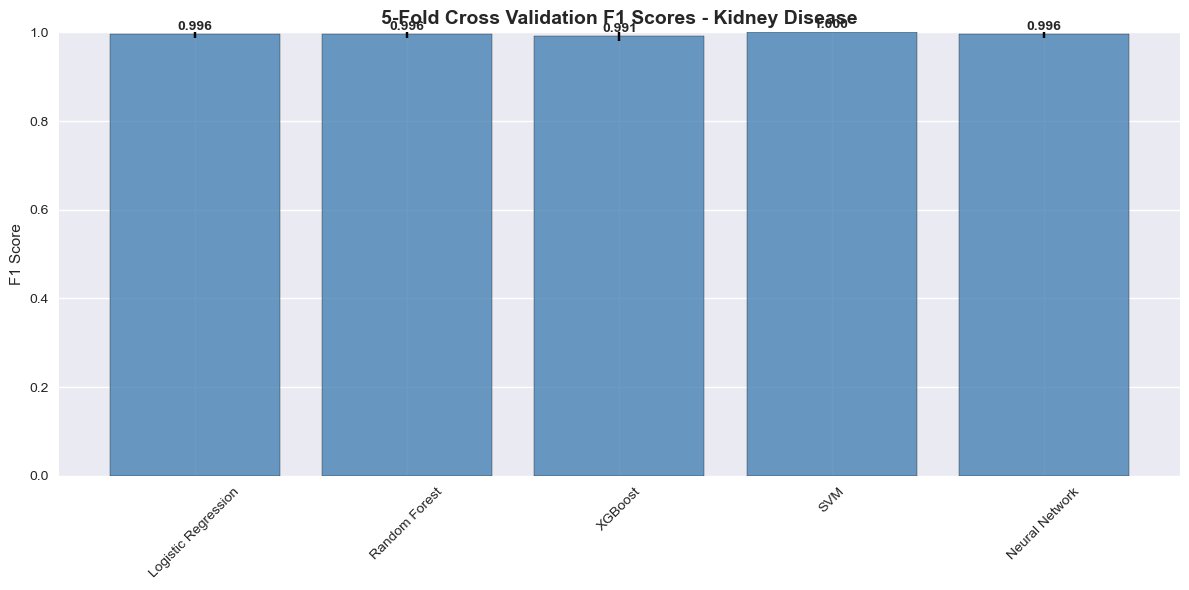

In [4]:
# Step 1: Cross Validation

print("=" * 50)
print("STEP 1: CROSS VALIDATION (5-FOLD)")
print("=" * 50)

cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=42)

base_models = {
    'Logistic Regression': LogisticRegression(random_state=42,
                                              max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100,
                                           random_state=42),
    'XGBoost': XGBClassifier(random_state=42,
                              eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50),
                                    max_iter=500,
                                    random_state=42)
}

cv_results = {}

print("Cross Validation Results:")
print("-" * 40)

for name, model in base_models.items():
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='f1')
    cv_results[name] = {
        'Mean F1': cv_scores.mean(),
        'Std F1': cv_scores.std(),
        'All Scores': cv_scores
    }
    print(f"\n{name}:")
    print(f"  Mean F1: {cv_scores.mean():.4f}")
    print(f"  Std F1:  {cv_scores.std():.4f}")
    print(f"  Scores:  {cv_scores.round(4)}")

plt.figure(figsize=(12, 6))
names = list(cv_results.keys())
means = [cv_results[n]['Mean F1'] for n in names]
stds = [cv_results[n]['Std F1'] for n in names]

bars = plt.bar(names, means, yerr=stds,
               color='steelblue', edgecolor='black',
               capsize=5, alpha=0.8)

for bar, mean in zip(bars, means):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{mean:.3f}', ha='center', fontweight='bold')

plt.title('5-Fold Cross Validation F1 Scores - Kidney Disease',
          fontweight='bold', fontsize=14)
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# Step 2: Hyperparameter Tuning
# Heavy regularization for small dataset

print("=" * 50)
print("STEP 2: HYPERPARAMETER TUNING")
print("=" * 50)

print("Tuning Random Forest...")
rf_params = {
    'n_estimators': [10, 30, 50],
    'max_depth': [2, 3, 4],        # Very shallow
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [3, 5, 10],# Large leaf size
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='f1',
    n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train)
print(f"Best RF Params: {rf_grid.best_params_}")
print(f"Best RF F1: {rf_grid.best_score_:.4f}")

print("\nTuning XGBoost...")
xgb_params = {
    'n_estimators': [20, 50],
    'max_depth': [2, 3],           # Very shallow
    'learning_rate': [0.01, 0.05],
    'subsample': [0.5, 0.6],
    'colsample_bytree': [0.5, 0.6],
    'reg_alpha': [1.0, 2.0],       # Strong L1
    'reg_lambda': [2.0, 5.0],      # Strong L2
    'min_child_weight': [10, 20]   # Large min samples
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params, cv=5, scoring='f1',
    n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train)
print(f"Best XGB Params: {xgb_grid.best_params_}")
print(f"Best XGB F1: {xgb_grid.best_score_:.4f}")

print("\nHyperparameter Tuning Complete!")

STEP 2: HYPERPARAMETER TUNING
Tuning Random Forest...
Best RF Params: {'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 30}
Best RF F1: 1.0000

Tuning XGBoost...
Best XGB Params: {'colsample_bytree': 0.5, 'learning_rate': 0.01, 'max_depth': 2, 'min_child_weight': 10, 'n_estimators': 50, 'reg_alpha': 1.0, 'reg_lambda': 2.0, 'subsample': 0.5}
Best XGB F1: 0.9956

Hyperparameter Tuning Complete!


In [6]:
# Step 3: Train Final Models

print("=" * 50)
print("STEP 3: TRAIN FINAL MODELS")
print("=" * 50)

final_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000),
    'Random Forest': rf_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_,
    'SVM': SVC(probability=True, random_state=42, C=1.0),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        max_iter=500, random_state=42)
}

results = {}

for name, model in final_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'AUC ROC': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'Model': model
    }

    print(f"Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"F1 Score:  {results[name]['F1 Score']:.4f}")
    print(f"AUC ROC:   {results[name]['AUC ROC']:.4f}")

print("\nAll Models Trained!")

STEP 3: TRAIN FINAL MODELS

Training Logistic Regression...
Accuracy:  1.0000
F1 Score:  1.0000
AUC ROC:   1.0000

Training Random Forest...
Accuracy:  1.0000
F1 Score:  1.0000
AUC ROC:   1.0000

Training XGBoost...
Accuracy:  1.0000
F1 Score:  1.0000
AUC ROC:   1.0000

Training SVM...
Accuracy:  0.9892
F1 Score:  0.9895
AUC ROC:   1.0000

Training Neural Network...
Accuracy:  1.0000
F1 Score:  1.0000
AUC ROC:   1.0000

All Models Trained!


                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Logistic Regression    1.0000        1.0  1.0000    1.0000      1.0
Random Forest          1.0000        1.0  1.0000    1.0000      1.0
XGBoost                1.0000        1.0  1.0000    1.0000      1.0
SVM                    0.9892        1.0  0.9792    0.9895      1.0
Neural Network         1.0000        1.0  1.0000    1.0000      1.0


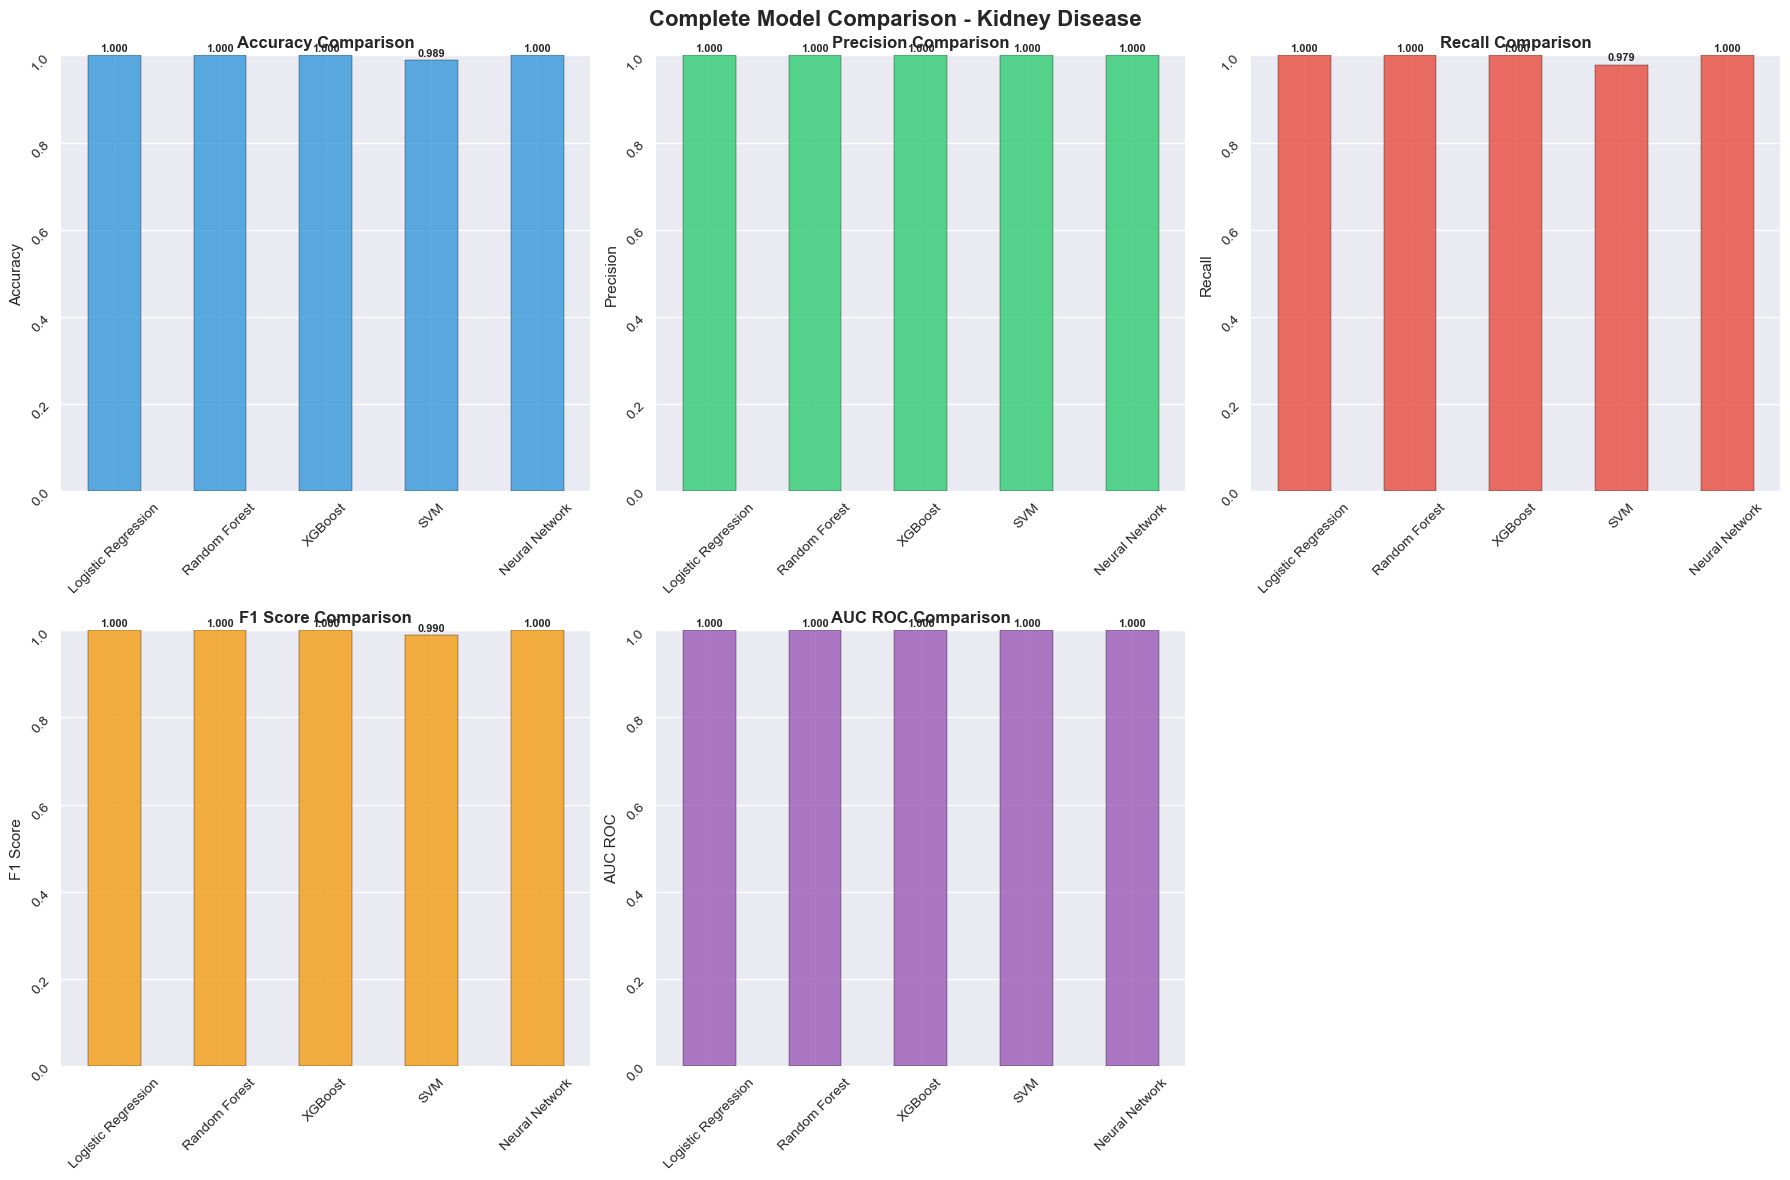

In [7]:
# Step 4: Model Comparison

results_df = pd.DataFrame({
    name: {
        'Accuracy': results[name]['Accuracy'],
        'Precision': results[name]['Precision'],
        'Recall': results[name]['Recall'],
        'F1 Score': results[name]['F1 Score'],
        'AUC ROC': results[name]['AUC ROC']
    }
    for name in results
}).T.round(4)

print(results_df)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision', 'Recall',
           'F1 Score', 'AUC ROC']
colors = ['#3498db', '#2ecc71', '#e74c3c',
          '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    results_df[metric].plot(kind='bar',
                            ax=axes[i],
                            color=colors[i],
                            edgecolor='black',
                            alpha=0.8)
    axes[i].set_title(f'{metric} Comparison',
                      fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(rotation=45)
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.01, f'{v:.3f}',
                    ha='center', fontsize=8,
                    fontweight='bold')

axes[5].set_visible(False)

plt.suptitle('Complete Model Comparison - Kidney Disease',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

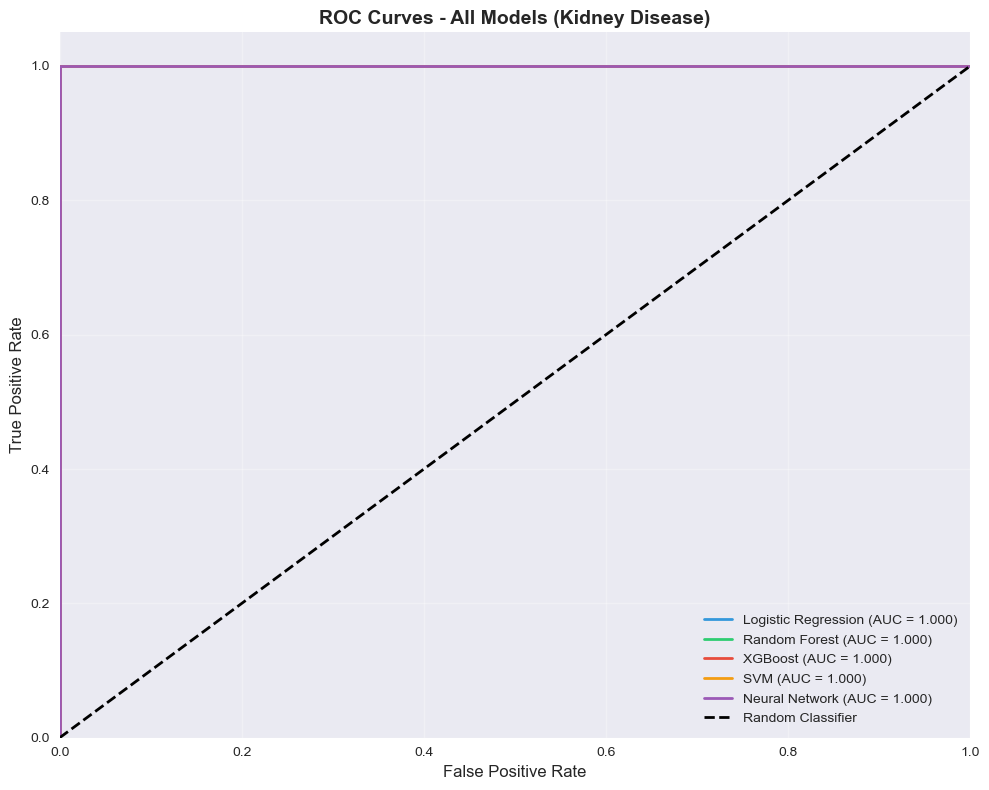

In [8]:
# Step 5: ROC Curve

plt.figure(figsize=(10, 8))

colors_roc = ['#3498db', '#2ecc71', '#e74c3c',
              '#f39c12', '#9b59b6']

for (name, result), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, result['y_prob'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2,
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - All Models (Kidney Disease)',
          fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Best Model: Logistic Regression
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
AUC ROC:   1.0000


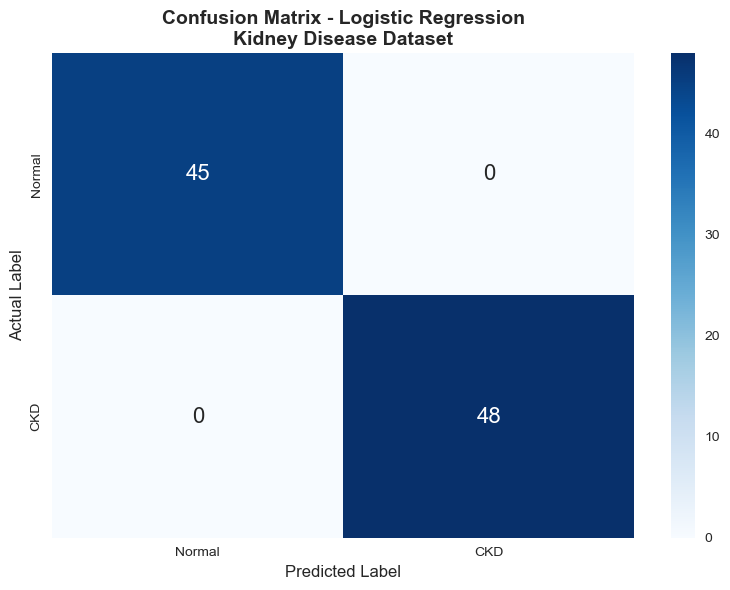

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00        45
         CKD       1.00      1.00      1.00        48

    accuracy                           1.00        93
   macro avg       1.00      1.00      1.00        93
weighted avg       1.00      1.00      1.00        93



In [9]:
# Step 6: Best Model & Confusion Matrix

best_model_name = results_df['F1 Score'].idxmax()
best_model = results[best_model_name]['Model']
y_pred_best = results[best_model_name]['y_pred']

print(f"Best Model: {best_model_name}")
print(f"Accuracy:  {results[best_model_name]['Accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['Precision']:.4f}")
print(f"Recall:    {results[best_model_name]['Recall']:.4f}")
print(f"F1 Score:  {results[best_model_name]['F1 Score']:.4f}")
print(f"AUC ROC:   {results[best_model_name]['AUC ROC']:.4f}")

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['Normal', 'CKD'],
            yticklabels=['Normal', 'CKD'],
            annot_kws={'size': 16})
plt.title(f'Confusion Matrix - {best_model_name}\n'
          f'Kidney Disease Dataset',
          fontweight='bold', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_best,
      target_names=['Normal', 'CKD']))

STEP 7: SHAP EXPLAINABILITY


  0%|          | 0/93 [00:00<?, ?it/s]

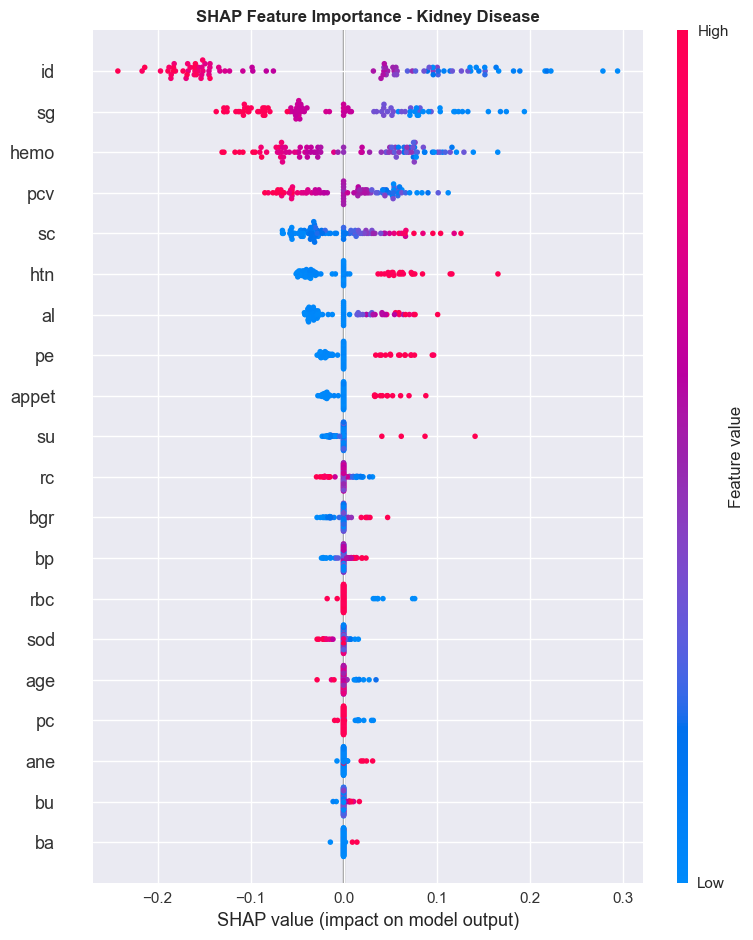

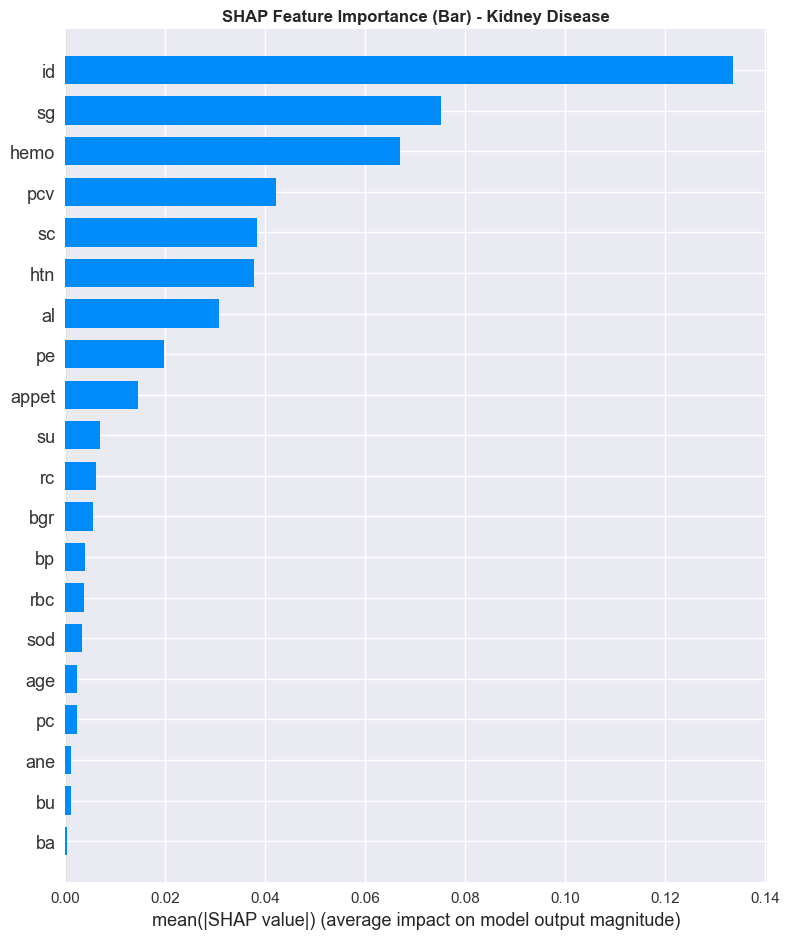

SHAP Analysis Complete!

Top Features by SHAP:
id       0.133601
sg       0.075259
hemo     0.066883
pcv      0.042123
sc       0.038306
htn      0.037733
al       0.030691
pe       0.019838
appet    0.014671
su       0.006955
rc       0.006194
bgr      0.005664
bp       0.004027
rbc      0.003834
sod      0.003337
age      0.002461
pc       0.002393
ane      0.001278
bu       0.001191
ba       0.000431
pcc      0.000300
wc       0.000243
pot      0.000050
dm       0.000040
cad      0.000000
dtype: float64


In [10]:
# Step 7: SHAP Explainability

print("=" * 50)
print("STEP 7: SHAP EXPLAINABILITY")
print("=" * 50)

if best_model_name in ['Random Forest', 'XGBoost']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.KernelExplainer(
        best_model.predict_proba,
        shap.sample(X_train, 100))

shap_values = explainer.shap_values(X_test)

# Fix for 2D SHAP values
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
elif len(np.array(shap_values).shape) == 3:
    shap_vals = shap_values[:, :, 1]
else:
    shap_vals = shap_values

# Make sure 2D
if len(shap_vals.shape) > 2:
    shap_vals = shap_vals[:, :, 1]

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_test,
                  feature_names=X_train.columns.tolist(),
                  show=False)
plt.title('SHAP Feature Importance - Kidney Disease',
          fontweight='bold')
plt.tight_layout()
plt.savefig('E:/HealthGuard_AI/reports/kidney_shap.png',
            dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals, X_test,
                  feature_names=X_train.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Bar) - Kidney Disease',
          fontweight='bold')
plt.tight_layout()
plt.show()

print("SHAP Analysis Complete!")

# Fix for 1D conversion
shap_importance = pd.Series(
    np.abs(shap_vals).mean(axis=0).flatten(),
    index=X_train.columns
).sort_values(ascending=False)

print("\nTop Features by SHAP:")
print(shap_importance)

In [11]:
# Step 8: Save Model

model_path = "E:/HealthGuard_AI/models/saved/kidney_model.pkl"

with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)

with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X_test[:5])
print(f"Model: {best_model_name}")
print(f"Saved at: {model_path}")
print(f"Verification: {test_pred}")
print("Model Saved and Verified!")

Model: Logistic Regression
Saved at: E:/HealthGuard_AI/models/saved/kidney_model.pkl
Verification: [0 0 1 0 0]
Model Saved and Verified!


In [12]:
# Final Summary

print("=" * 60)
print("   KIDNEY DISEASE MODEL TRAINING - FINAL SUMMARY")
print("=" * 60)

print("\nCROSS VALIDATION RESULTS:")
print("-" * 40)
for name, cv in cv_results.items():
    print(f"{name}: {cv['Mean F1']:.4f} (+/- {cv['Std F1']:.4f})")

print("\nFINAL MODEL PERFORMANCE:")
print("-" * 40)
print(results_df.to_string())

print(f"\nBEST MODEL: {best_model_name}")
print(f"Accuracy:  {results[best_model_name]['Accuracy']:.4f}")
print(f"Precision: {results[best_model_name]['Precision']:.4f}")
print(f"Recall:    {results[best_model_name]['Recall']:.4f}")
print(f"F1 Score:  {results[best_model_name]['F1 Score']:.4f}")
print(f"AUC ROC:   {results[best_model_name]['AUC ROC']:.4f}")

print(f"\nModel saved: kidney_model.pkl")
print("\nKidney Disease Model Training Complete! ")
print("=" * 60)

   KIDNEY DISEASE MODEL TRAINING - FINAL SUMMARY

CROSS VALIDATION RESULTS:
----------------------------------------
Logistic Regression: 0.9956 (+/- 0.0089)
Random Forest: 0.9956 (+/- 0.0089)
XGBoost: 0.9913 (+/- 0.0107)
SVM: 1.0000 (+/- 0.0000)
Neural Network: 0.9956 (+/- 0.0089)

FINAL MODEL PERFORMANCE:
----------------------------------------
                     Accuracy  Precision  Recall  F1 Score  AUC ROC
Logistic Regression    1.0000        1.0  1.0000    1.0000      1.0
Random Forest          1.0000        1.0  1.0000    1.0000      1.0
XGBoost                1.0000        1.0  1.0000    1.0000      1.0
SVM                    0.9892        1.0  0.9792    0.9895      1.0
Neural Network         1.0000        1.0  1.0000    1.0000      1.0

BEST MODEL: Logistic Regression
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000
AUC ROC:   1.0000

Model saved: kidney_model.pkl

Kidney Disease Model Training Complete! 


In [13]:
# Verify All Models Saved

import os
import pickle

models_info = {
    "diabetes_model.pkl": "Diabetes",
    "heart_model.pkl": "Heart Disease",
    "hypertension_model.pkl": "Hypertension",
    "stroke_model.pkl": "Stroke",
    "kidney_model.pkl": "Kidney Disease"
}

print("=" * 60)
print("   CHECKING ALL SAVED MODELS - HEALTHGUARD AI")
print("=" * 60)

path = "E:/HealthGuard_AI/models/saved/"

for filename, disease in models_info.items():
    full_path = path + filename
    if os.path.exists(full_path):
        size = os.path.getsize(full_path) / 1024
        print(f" {disease}: {filename} ({size:.1f} KB)")
    else:
        print(f"❌ {disease}: {filename} - MISSING")

print("\n" + "=" * 60)
print("All 5 Models Ready!")
print("Next Step: Web Application Development!")
print("=" * 60)

   CHECKING ALL SAVED MODELS - HEALTHGUARD AI
 Diabetes: diabetes_model.pkl (1837.0 KB)
 Heart Disease: heart_model.pkl (19.1 KB)
 Hypertension: hypertension_model.pkl (119.5 KB)
 Stroke: stroke_model.pkl (205.7 KB)
 Kidney Disease: kidney_model.pkl (1.1 KB)

All 5 Models Ready!
Next Step: Web Application Development!
